### 1.1 Datenabruf und Filterung

Vorschlag: Daten ohne Limit einmal als csv runterladen. Ist dadurch reproduzierbarer

In [ ]:
# Stationsmetadaten und gueltige Tageswerte zusammenfuehren

from wetterdienst import Settings
from wetterdienst.provider.dwd.observation import DwdObservationRequest
import pandas as pd
import os

# Cache aktiv lassen, damit wiederholte Abfragen schneller sind
settings = Settings(cache_disable=False)

date = "2026-04-17"
csv_file = f"stations_data_{date}.csv"

# CSV laden oder neu herunterladen
if os.path.exists(csv_file):
    print(f"Lade Daten aus {csv_file}...")
    stations_with_data = pd.read_csv(csv_file)
    print(f"Anzahl Stationen mit gueltigem Wert: {len(stations_with_data)}")
else:
    print(f"Lade Daten vom DWD für {date}...")
    
    request = DwdObservationRequest(
        parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
        start_date=date,
        end_date=date,
        settings=settings,
    )
    
    stations = request.all().df.to_pandas()
    values = request.all().values.all().df.to_pandas()
    values["value"] = pd.to_numeric(values["value"], errors="coerce")
    
    stations_with_data = stations.merge(
        values.loc[values["value"].notna(), ["station_id", "value"]],
        on="station_id",
        how="inner",
    )
    
    # Speichere als CSV für zukünftige Nutzung
    stations_with_data.to_csv(csv_file, index=False)
    print(f"Anzahl Stationen mit gueltigem Wert: {len(stations_with_data)}")
    print(f"Daten gespeichert in {csv_file}")

stations_with_data


Lade Daten vom DWD für 2026-03-17 bis 2026-04-17...


KeyboardInterrupt: 

### 1.2 Deutschland laden & Daten projezieren

In [ ]:
# Deutschland laden (inkl. Inseln) und Stationen projizieren

import geopandas as gpd
import numpy as np
from pyproj import Transformer

# GeoPandas lädt alle Polygone (Festland + Inseln) und projiziert nach EPSG:3035
germany = gpd.read_file("de.json").to_crs("EPSG:3035")
germany_geom = germany.geometry.unary_union  # MultiPolygon mit Festland + allen Inseln

# Stationen projizieren
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

sx, sy = transformer.transform(
    stations_with_data["longitude"].to_numpy(),
    stations_with_data["latitude"].to_numpy(),
)

stations_with_data = stations_with_data.copy()
stations_with_data["x"] = sx
stations_with_data["y"] = sy


In [ ]:
# Zielraster und Maskierung vorbereiten (alle Polygone inkl. Inseln)

from matplotlib.path import Path

min_x, min_y, max_x, max_y = germany_geom.bounds

grid_x, grid_y = np.meshgrid(
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

targets = np.column_stack([grid_x.ravel(), grid_y.ravel()])

# Maske über alle Teilpolygone (Festland + Inseln)
inside_mask = np.zeros(len(targets), dtype=bool)
for poly in germany_geom.geoms:
    inside_mask |= Path(np.array(poly.exterior.coords)).contains_points(targets)

inside_mask = inside_mask.reshape(grid_x.shape)


In [4]:
# PyKrige auf projizierten Stationspunkten und Zielachsen ausführen

from pykrige.ok import OrdinaryKriging

ok = OrdinaryKriging(
    x=stations_with_data["x"].to_numpy(),
    y=stations_with_data["y"].to_numpy(),
    z=stations_with_data["value"].to_numpy(),
    variogram_model="spherical",
    coordinates_type="euclidean",
)

z_pred, z_var = ok.execute(
    "grid",
    np.linspace(min_x, max_x, 140),
    np.linspace(min_y, max_y, 170),
)

z_pred = np.where(inside_mask, np.asarray(z_pred, dtype=float), np.nan)
z_var = np.where(inside_mask, np.asarray(z_var, dtype=float), np.nan)


In [5]:
# Historische Reihe bis Ende 2025 auf Monatsmittel bringen

from statsmodels.tsa.seasonal import STL

station = DwdObservationRequest(
    parameters=("daily", "climate_summary", "temperature_air_mean_2m"),
    start_date="1880-01-01",
    end_date="2025-12-31",
    settings=settings,
).filter_by_name(name="Chemnitz")

values = station.values.all().df.to_pandas()
values["date"] = pd.to_datetime(values["date"], utc=True)
values["value"] = pd.to_numeric(values["value"], errors="coerce")

monthly = (
    values.dropna(subset=["value"])
    .set_index("date")["value"]
    .resample("ME")
    .mean()
)

stl = STL(monthly, period=12, robust=True).fit()


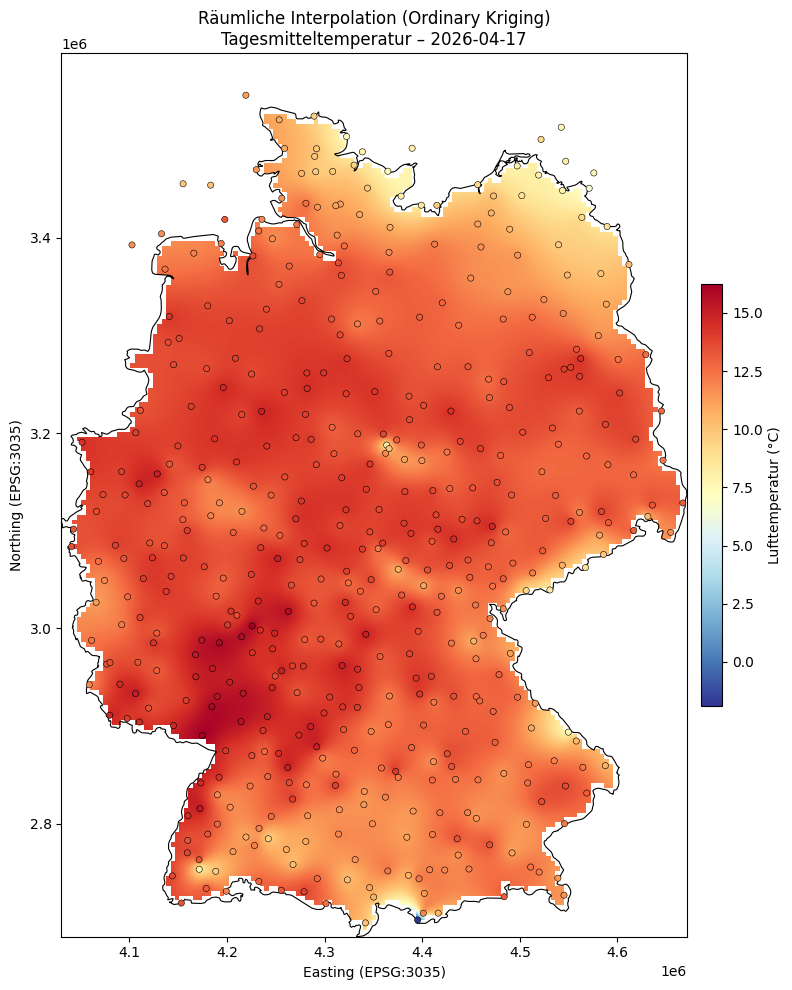

In [ ]:
# Interpolationskarte visualisieren

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

img = ax.imshow(
    z_pred,
    extent=[min_x, max_x, min_y, max_y],
    origin="lower",
    cmap="RdYlBu_r",
    interpolation="bilinear",
)

# Alle Polygone zeichnen (Festland + Inseln)
for poly in germany_geom.geoms:
    coords = np.array(poly.exterior.coords)
    ax.plot(coords[:, 0], coords[:, 1], color="black", linewidth=0.8)

ax.scatter(
    stations_with_data["x"],
    stations_with_data["y"],
    c=stations_with_data["value"],
    cmap="RdYlBu_r",
    edgecolors="black",
    linewidths=0.4,
    s=20,
    zorder=5,
    norm=img.norm,
)

cbar = fig.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Lufttemperatur (°C)")

ax.set_title(f"Räumliche Interpolation (Ordinary Kriging)\nTagesmitteltemperatur – {date}", fontsize=12)
ax.set_xlabel("Easting (EPSG:3035)")
ax.set_ylabel("Northing (EPSG:3035)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


Inseln müssen angezeigt werden geopanda verwenden